# Autoencoders (AE) sur 10% de MNIST

Ce notebook prolonge le même pipeline que les autres notebooks du projet sur un sous-échantillon stratifié de 10% de MNIST.
On utilise PyTorch pour un autoencoder natif, puis on garde la logique déjà utilisée ailleurs : préparation des données, recherche d'hyperparamètres, validation, test et visualisations finales.

In [3]:
import sys
import subprocess
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

try:
    import optuna
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "--quiet"])
    import optuna

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
print("Chargement de MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=0.10,
    stratify=y,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sample,
    y_sample,
    test_size=0.30,
    stratify=y_sample,
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print(f"X total        : {X.shape}")
print(f"X 10% sample   : {X_sample.shape}")
print(f"Train / Val / Test : {X_train.shape} / {X_val.shape} / {X_test.shape}")
print("Distribution train:", np.bincount(y_train))
print("Distribution val  :", np.bincount(y_val))
print("Distribution test :", np.bincount(y_test))

Chargement de MNIST...
X total        : (70000, 784)
X 10% sample   : (7000, 784)
Train / Val / Test : (4900, 784) / (1050, 784) / (1050, 784)
Distribution train: [483 552 489 500 477 442 482 510 478 487]
Distribution val  : [104 118 105 107 103  94 103 109 102 105]
Distribution test : [103 118 105 107 102  95 103 110 103 104]


## Recherche d'hyperparamètres

On ajuste la capacité du réseau, la taille du goulot d'étranglement, l'activation et le rythme d'apprentissage sur le jeu d'entraînement, puis on valide sur le jeu de validation.

In [10]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_multiplier, activation="relu"):
        super().__init__()
        hidden_dim = latent_dim * hidden_multiplier
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            self._make_activation(activation),
            nn.Linear(hidden_dim, latent_dim),
            self._make_activation(activation),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            self._make_activation(activation),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def _make_activation(self, activation):
        if activation == "tanh":
            return nn.Tanh()
        return nn.ReLU()

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x)


def make_dataloader(X_array, batch_size, shuffle):
    tensor = torch.tensor(X_array, dtype=torch.float32)
    dataset = TensorDataset(tensor, tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_autoencoder(model, train_loader, val_loader, learning_rate, alpha, max_epochs, patience=6):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=alpha)
    criterion = nn.MSELoss()
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            recon = model(xb)
            loss = criterion(recon, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                recon = model(xb)
                val_losses.append(criterion(recon, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_val


def evaluate_autoencoder(model, X_array, batch_size=256):
    loader = make_dataloader(X_array, batch_size=batch_size, shuffle=False)
    model.eval()
    preds = []
    latents = []
    criterion = nn.MSELoss(reduction="sum")
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            z = model.encode(xb)
            recon = model(xb)
            latents.append(z.cpu().numpy())
            preds.append(recon.cpu().numpy())
            total_loss += criterion(recon, yb).item()
    recon_array = np.vstack(preds)
    latent_array = np.vstack(latents)
    mse = total_loss / (len(X_array) * X_array.shape[1])
    return recon_array, latent_array, mse

In [5]:
def objective(trial):
    latent_dim = trial.suggest_categorical("latent_dim", [16, 32, 64, 128])
    hidden_multiplier = trial.suggest_categorical("hidden_multiplier", [2, 3, 4])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    max_epochs = trial.suggest_int("max_epochs", 20, 50, step=10)

    model = DenseAutoencoder(
        input_dim=X_train.shape[1],
        latent_dim=latent_dim,
        hidden_multiplier=hidden_multiplier,
        activation=activation,
    ).to(device)

    train_loader = make_dataloader(X_train, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(X_val, batch_size=batch_size, shuffle=False)

    try:
        started_at = time.time()
        trained_model, history, best_val = train_autoencoder(
            model,
            train_loader,
            val_loader,
            learning_rate=learning_rate,
            alpha=alpha,
            max_epochs=max_epochs,
            patience=5,
        )
        trial.set_user_attr("fit_time", time.time() - started_at)
        trial.set_user_attr("hidden_dim", latent_dim * hidden_multiplier)
        trial.set_user_attr("epochs", int(history["epoch"].iloc[-1]))
        return best_val
    except Exception as error:
        trial.set_user_attr("error", str(error))
        return float("inf")


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=12, show_progress_bar=False)

best_params = study.best_trial.params
best_params["hidden_dim"] = best_params["latent_dim"] * best_params["hidden_multiplier"]

print("Meilleurs hyperparamètres :")
print(best_params)
print(f"Meilleure MSE de validation : {study.best_value:.6f}")

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
trials_df = trials_df.sort_values("value")
trials_df.head(5)

[I 2026-05-06 03:29:18,643] A new study created in memory with name: no-name-f6092161-7b1b-4e35-9aa1-2292bbea47ad
[I 2026-05-06 03:29:39,269] Trial 0 finished with value: 0.05806814353255665 and parameters: {'latent_dim': 32, 'hidden_multiplier': 2, 'activation': 'relu', 'alpha': 0.000133112160807369, 'learning_rate': 0.00010725209743172001, 'batch_size': 64, 'max_epochs': 20}. Best is trial 0 with value: 0.05806814353255665.
[I 2026-05-06 03:29:48,320] Trial 1 finished with value: 0.05108648762106895 and parameters: {'latent_dim': 64, 'hidden_multiplier': 3, 'activation': 'tanh', 'alpha': 2.334586407601622e-05, 'learning_rate': 0.0014447746112718689, 'batch_size': 256, 'max_epochs': 20}. Best is trial 1 with value: 0.05108648762106895.
[I 2026-05-06 03:30:04,073] Trial 2 finished with value: 0.06759820580482483 and parameters: {'latent_dim': 128, 'hidden_multiplier': 2, 'activation': 'tanh', 'alpha': 2.091498132903561e-05, 'learning_rate': 0.00015144860262751404, 'batch_size': 256, 'm

Meilleurs hyperparamètres :
{'latent_dim': 128, 'hidden_multiplier': 4, 'activation': 'tanh', 'alpha': 1.062287572810087e-06, 'learning_rate': 0.0008119294067650657, 'batch_size': 64, 'max_epochs': 50, 'hidden_dim': 512}
Meilleure MSE de validation : 0.006514


,number,value,params_activation,params_alpha,params_batch_size,params_hidden_multiplier,params_latent_dim,params_learning_rate,params_max_epochs,user_attrs_epochs,user_attrs_fit_time,user_attrs_hidden_dim
11,11,0.006514,tanh,0.000001,64,4,128,0.000812,50,50,75.188689,512
10,10,0.006517,tanh,0.000001,64,4,128,0.000704,50,50,94.642256,512
6,6,0.023441,relu,0.000002,64,2,64,0.000111,50,50,44.959245,128
7,7,0.024500,relu,0.000079,256,3,64,0.001938,40,40,18.875119,192
8,8,0.027155,relu,0.000034,256,4,32,0.000414,50,50,18.544311,128


In [11]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.hstack([y_train, y_val])

final_model = DenseAutoencoder(
    input_dim=X_train.shape[1],
    latent_dim=best_params["latent_dim"],
    hidden_multiplier=best_params["hidden_multiplier"],
    activation=best_params["activation"],
).to(device)

trainval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=True)
trainval_eval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=False)
test_loader = make_dataloader(X_test, batch_size=best_params["batch_size"], shuffle=False)

started_at = time.time()
final_model, final_history, _ = train_autoencoder(
    final_model,
    trainval_loader,
    trainval_eval_loader,
    learning_rate=best_params["learning_rate"],
    alpha=best_params["alpha"],
    max_epochs=max(best_params["max_epochs"], 50),
    patience=8,
)
trainval_fit_time = time.time() - started_at

X_test_recon, latent_test, test_mse = evaluate_autoencoder(final_model, X_test, batch_size=best_params["batch_size"])
X_trainval_recon, latent_train, train_mse = evaluate_autoencoder(final_model, X_trainval, batch_size=best_params["batch_size"])

test_rmse = math.sqrt(test_mse)
test_mae = mean_absolute_error(X_test, X_test_recon)

print("Évaluation finale sur le test :")
print(f"Train+Val MSE : {train_mse:.6f}")
print(f"Test MSE      : {test_mse:.6f}")
print(f"Test RMSE     : {test_rmse:.6f}")
print(f"Test MAE      : {test_mae:.6f}")
print(f"Temps d'entraînement final : {trainval_fit_time:.1f}s")
print(f"Latent shape  : {latent_test.shape}")
print(f"Compression   : 784 -> {best_params['latent_dim']}")

Évaluation finale sur le test :
Train+Val MSE : 0.003723
Test MSE      : 0.005522
Test RMSE     : 0.074309
Test MAE      : 0.027560
Temps d'entraînement final : 107.4s
Latent shape  : (1050, 128)
Compression   : 784 -> 128


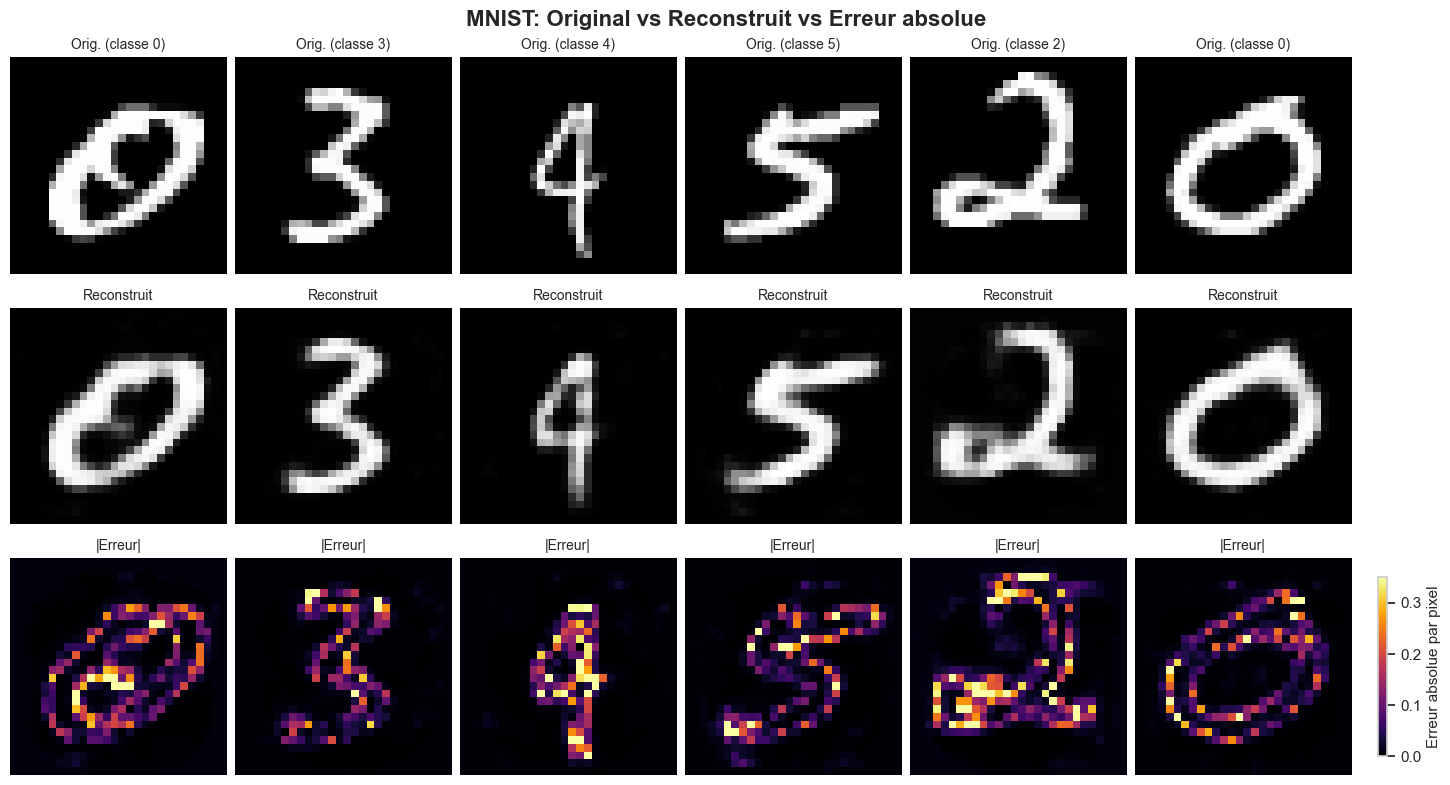

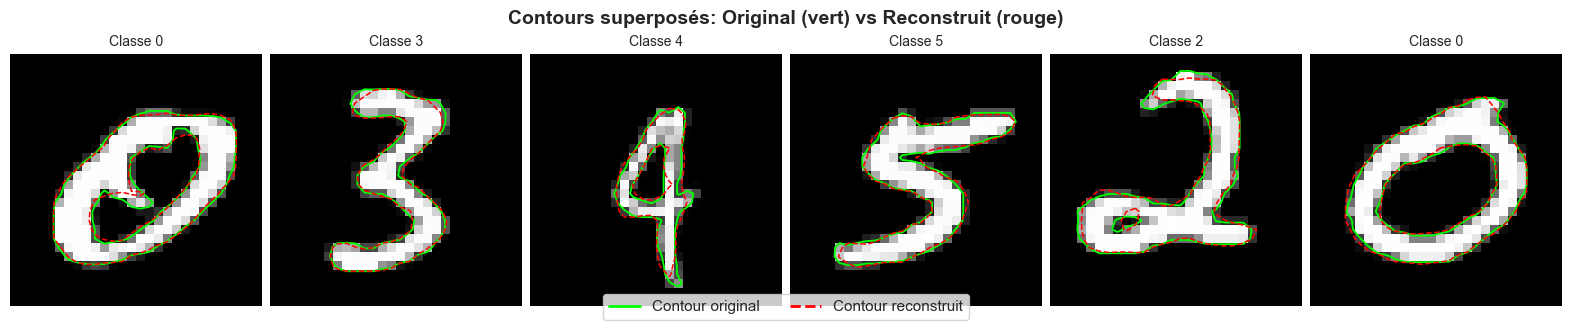

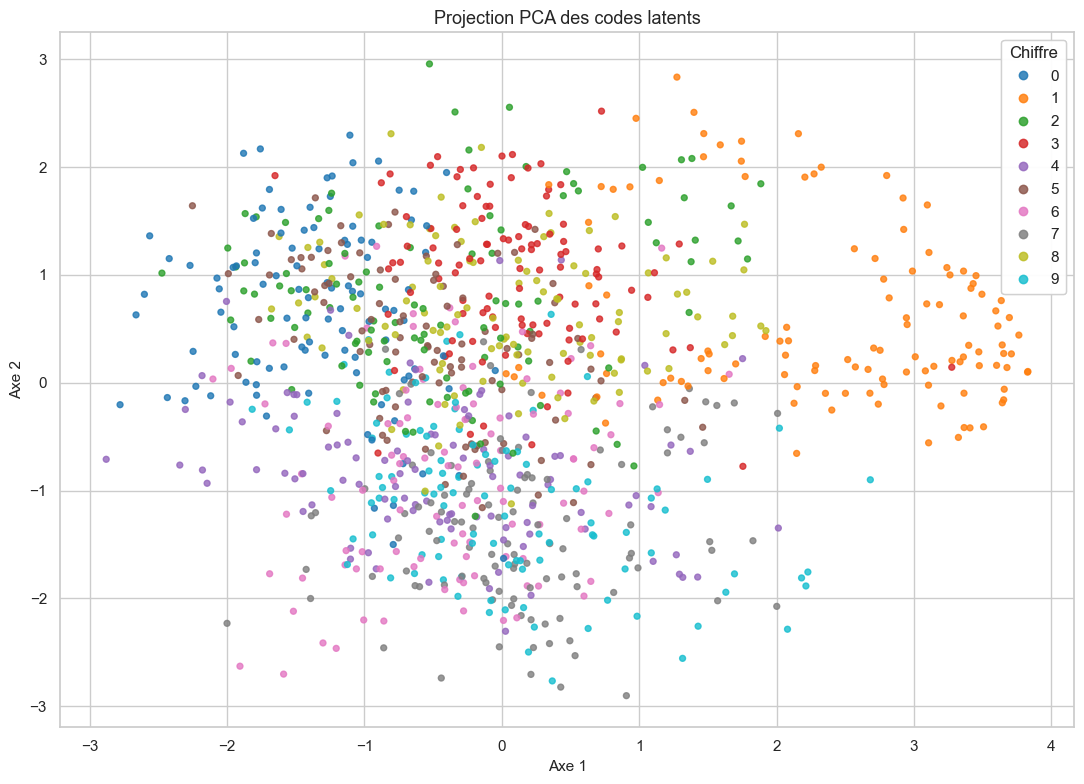

,Metric,Value
0,Validation MSE,0.006514
1,Test MSE,0.005522
2,Test RMSE,0.074309
3,Test MAE,0.027560
4,Latent dim,128.000000


In [15]:
from matplotlib.lines import Line2D

n_show = 6
sample_idx = np.arange(n_show)

fig, axes = plt.subplots(3, n_show, figsize=(2.4 * n_show, 7.8), constrained_layout=True)
fig.suptitle("MNIST: Original vs Reconstruit vs Erreur absolue", fontsize=16, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)
    abs_err = np.abs(original_img - recon_img)

    axes[0, col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Orig. (classe {y_test[idx]})", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(recon_img, cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title("Reconstruit", fontsize=10)
    axes[1, col].axis("off")

    err_im = axes[2, col].imshow(abs_err, cmap="inferno", vmin=0, vmax=0.35)
    axes[2, col].set_title("|Erreur|", fontsize=10)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruit", fontsize=11)
axes[2, 0].set_ylabel("Erreur", fontsize=11)

cbar = fig.colorbar(err_im, ax=axes[2, :], shrink=0.78, pad=0.02)
cbar.set_label("Erreur absolue par pixel")

plt.show()

# Vue superposée par contours: vert=original, rouge pointillé=reconstruction
fig2, axes2 = plt.subplots(1, n_show, figsize=(2.6 * n_show, 3.2), constrained_layout=True)
fig2.suptitle("Contours superposés: Original (vert) vs Reconstruit (rouge)", fontsize=14, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)

    axes2[col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes2[col].contour(original_img, levels=[0.35], colors=["lime"], linewidths=1.3)
    axes2[col].contour(recon_img, levels=[0.35], colors=["red"], linewidths=1.1, linestyles="--")
    axes2[col].set_title(f"Classe {y_test[idx]}", fontsize=10)
    axes2[col].axis("off")

legend_handles = [
    Line2D([0], [0], color="lime", linewidth=2, label="Contour original"),
    Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Contour reconstruit"),
]
fig2.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=True)
plt.show()

if latent_test.shape[1] > 2:
    latent_vis = PCA(n_components=2, random_state=42).fit_transform(latent_test)
    latent_title = "Projection PCA des codes latents"
else:
    latent_vis = latent_test
    latent_title = "Espace latent 2D"

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    latent_vis[:, 0],
    latent_vis[:, 1],
    c=y_test,
    cmap="tab10",
    s=18,
    alpha=0.8,
)
ax.set_title(latent_title)
ax.set_xlabel("Axe 1")
ax.set_ylabel("Axe 2")
legend = ax.legend(*scatter.legend_elements(), title="Chiffre", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    {"Metric": "Validation MSE", "Value": study.best_value},
    {"Metric": "Test MSE", "Value": test_mse},
    {"Metric": "Test RMSE", "Value": test_rmse},
    {"Metric": "Test MAE", "Value": test_mae},
    {"Metric": "Latent dim", "Value": best_params["latent_dim"]}
])
summary